In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from scipy import stats

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [59]:
INPUT_FOLDER = Path(
    r"C:\Users\bhara\OneDrive\Desktop\DAMO-699-Capstone-Project-Unofficial-\DAMO-699-Capstone-Project-Unofficial-\data\Explorer Dataset"
)

FILE_PATH = INPUT_FOLDER / "CTAS_Triage.csv"

print("Input file:")
print(FILE_PATH)

print("\nFile exists:", FILE_PATH.exists())

Input file:
C:\Users\bhara\OneDrive\Desktop\DAMO-699-Capstone-Project-Unofficial-\DAMO-699-Capstone-Project-Unofficial-\data\Explorer Dataset\CTAS_Triage.csv

File exists: True


In [60]:
df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [61]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,10332,240,4.0000
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20–44,Young Adult,11051,330,5.5000
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45–64,Middle Adult,11653,324,5.4000
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414,6.9000
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,12409,228,3.8000
5,2021-2022,2021,Male,CTAS I - Resuscitation,1,20–44,Young Adult,18848,336,5.6000
6,2021-2022,2021,Male,CTAS I - Resuscitation,1,45–64,Middle Adult,20762,300,5.0000
7,2021-2022,2021,Male,CTAS I - Resuscitation,1,65+,Older Adult,30338,360,6.0000
8,2021-2022,2021,Female,CTAS II - Emergent,2,00–19,Pediatric & Youth,208386,228,3.8000
9,2021-2022,2021,Female,CTAS II - Emergent,2,20–44,Young Adult,416879,282,4.7000


In [62]:
print("LAST 10 ROWS")
print("-" * 80)

display(df.tail(10))

LAST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
902,2003-2004,2003,Male,Non-urgent,3,20–44,Young Adult,137821,72,1.2000
903,2003-2004,2003,Male,Unknown,3,20–44,Young Adult,264,31,0.5200
904,2003-2004,2003,Male,CTAS III - Urgent,3,45–64,Middle Adult,171087,200,3.3300
905,2003-2004,2003,Male,Less urgent,3,45–64,Middle Adult,194578,105,1.7500
906,2003-2004,2003,Male,Non-urgent,3,45–64,Middle Adult,82423,67,1.1200
907,2003-2004,2003,Male,Unknown,3,45–64,Middle Adult,103,44,0.7300
908,2003-2004,2003,Male,CTAS III - Urgent,3,65+,Older Adult,168123,252,4.2000
909,2003-2004,2003,Male,Less urgent,3,65+,Older Adult,114653,129,2.1500
910,2003-2004,2003,Male,Non-urgent,3,65+,Older Adult,48303,66,1.1000
911,2003-2004,2003,Male,Unknown,3,65+,Older Adult,50,27,0.4500


In [63]:
print("DATASET SHAPE")
print("-" * 80)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

DATASET SHAPE
--------------------------------------------------------------------------------
Rows    : 912
Columns : 10


In [64]:
print("COLUMN NAMES")
print("-" * 80)

for i, column in enumerate(df.columns, start=1):

    print(f"{i:02d}. {column}")

COLUMN NAMES
--------------------------------------------------------------------------------
01. fiscal_year
02. fiscal_year_start
03. sex
04. triage_level
05. ctas_urgency_score
06. age_group
07. population_category
08. ed_visits
09. median_los_minutes
10. median_los_hours


In [65]:
print("DATA TYPES")
print("-" * 80)

display(
    pd.DataFrame({
        "Column": df.columns,
        "Data_Type": df.dtypes.astype(str).values
    })
)

DATA TYPES
--------------------------------------------------------------------------------


,Column,Data_Type
0,fiscal_year,str
1,fiscal_year_start,int64
2,sex,str
3,triage_level,str
4,ctas_urgency_score,int64
5,age_group,str
6,population_category,str
7,ed_visits,int64
8,median_los_minutes,int64
9,median_los_hours,float64


In [66]:
missing_summary = pd.DataFrame({

    "Column": df.columns,

    "Missing_Count": [
        df[col].isna().sum()
        for col in df.columns
    ],

    "Missing_Percentage": [
        df[col].isna().mean() * 100
        for col in df.columns
    ]

})

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Percentage"]
    .round(2)
)

display(missing_summary)

,Column,Missing_Count,Missing_Percentage
0,fiscal_year,0,0.0000
1,fiscal_year_start,0,0.0000
2,sex,0,0.0000
3,triage_level,0,0.0000
4,ctas_urgency_score,0,0.0000
5,age_group,0,0.0000
6,population_category,0,0.0000
7,ed_visits,0,0.0000
8,median_los_minutes,0,0.0000
9,median_los_hours,0,0.0000


In [67]:
duplicate_count = df.duplicated().sum()

print("DUPLICATE RECORDS")
print("-" * 80)

print(f"Duplicate rows: {duplicate_count:,}")

print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(df) * 100:.2f}%"
)

DUPLICATE RECORDS
--------------------------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%


In [68]:
print("NUMERICAL SUMMARY")
print("-" * 80)

display(
    df.describe(
        include="all"
    ).T
)

NUMERICAL SUMMARY
--------------------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,912,19,2021-2022,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fiscal_year_start,912.0000,NaN,NaN,NaN,"2,012.0000",5.4802,"2,003.0000","2,007.0000","2,012.0000","2,017.0000","2,021.0000"
sex,912,2,Female,456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
triage_level,912,6,CTAS I - Resuscitation,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ctas_urgency_score,912.0000,NaN,NaN,NaN,2.5000,0.7642,1.0000,2.0000,3.0000,3.0000,3.0000
age_group,912,4,00–19,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population_category,912,4,Pediatric & Youth,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ed_visits,912.0000,NaN,NaN,NaN,"192,722.5263","216,994.4773",45.0000,"13,992.2500","104,983.5000","300,080.7500","1,165,671.0000"
median_los_minutes,912.0000,NaN,NaN,NaN,166.1162,94.2613,10.0000,84.0000,144.0000,235.0000,420.0000
median_los_hours,912.0000,NaN,NaN,NaN,2.7686,1.5709,0.1700,1.4000,2.4000,3.9200,7.0000


In [69]:
print("CTAS TRIAGE LEVELS")
print("-" * 80)

ctas_counts = (
    df["triage_level"]
    .value_counts(dropna=False)
    .rename_axis("triage_level")
    .reset_index(name="record_count")
)

display(ctas_counts)

CTAS TRIAGE LEVELS
--------------------------------------------------------------------------------


,triage_level,record_count
0,CTAS I - Resuscitation,152
1,CTAS II - Emergent,152
2,CTAS III - Urgent,152
3,Less urgent,152
4,Non-urgent,152
5,Unknown,152


In [70]:
ctas_visits = (
    df.groupby("triage_level", dropna=False)
      ["ed_visits"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

ctas_visits.columns = [
    "triage_level",
    "total_ed_visits"
]

display(ctas_visits)

,triage_level,total_ed_visits
0,CTAS III - Urgent,72100128
1,Less urgent,58990020
2,CTAS II - Emergent,26742361
3,Non-urgent,15088331
4,Unknown,1555549
5,CTAS I - Resuscitation,1286555


In [71]:
los_summary = (
    df.groupby("triage_level", dropna=False)
      ["median_los_minutes"]
      .agg([
          "count",
          "min",
          "median",
          "mean",
          "max",
          "std"
      ])
      .reset_index()
)

display(los_summary)

,triage_level,count,min,median,mean,max,std
0,CTAS I - Resuscitation,152,135,244.5000,248.3158,414,59.5799
1,CTAS II - Emergent,152,167,258.0000,274.3224,420,71.2719
2,CTAS III - Urgent,152,130,201.5000,208.3947,348,54.5498
3,Less urgent,152,90,114.0000,122.6382,228,25.6527
4,Non-urgent,152,65,78.0000,82.3289,126,15.2970
5,Unknown,152,10,66.0000,60.6974,108,23.7665


In [72]:
def weighted_mean(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values) &
        np.isfinite(weights) &
        (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.nan

    return np.average(
        values,
        weights=weights
    )


def weighted_median(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values) &
        np.isfinite(weights) &
        (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.nan

    order = np.argsort(values)

    values = values[order]
    weights = weights[order]

    cumulative_weights = np.cumsum(weights)

    midpoint = weights.sum() / 2

    return values[
        np.searchsorted(
            cumulative_weights,
            midpoint
        )
    ]


weighted_summary = (
    df.groupby("triage_level")
      .apply(
          lambda x: pd.Series({

              "records":
                  len(x),

              "total_ed_visits":
                  x["ed_visits"].sum(),

              "weighted_mean_los_minutes":
                  weighted_mean(
                      x["median_los_minutes"],
                      x["ed_visits"]
                  ),

              "weighted_median_los_minutes":
                  weighted_median(
                      x["median_los_minutes"],
                      x["ed_visits"]
                  ),

              "minimum_los_minutes":
                  x["median_los_minutes"].min(),

              "maximum_los_minutes":
                  x["median_los_minutes"].max()

          }),
          include_groups=False
      )
      .reset_index()
)

display(weighted_summary)

,triage_level,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,CTAS I - Resuscitation,152.0000,"1,286,555.0000",281.6537,276.0000,135.0000,414.0000
1,CTAS II - Emergent,152.0000,"26,742,361.0000",291.0076,288.0000,167.0000,420.0000
2,CTAS III - Urgent,152.0000,"72,100,128.0000",212.6773,204.0000,130.0000,348.0000
3,Less urgent,152.0000,"58,990,020.0000",122.5444,114.0000,90.0000,228.0000
4,Non-urgent,152.0000,"15,088,331.0000",86.7624,80.0000,65.0000,126.0000
5,Unknown,152.0000,"1,555,549.0000",72.9951,72.0000,10.0000,108.0000


In [73]:
print("FISCAL YEAR COVERAGE")
print("-" * 80)

fiscal_years = (
    df[
        [
            "fiscal_year_start",
            "fiscal_year"
        ]
    ]
    .drop_duplicates()
    .sort_values("fiscal_year_start")
)

display(fiscal_years)

FISCAL YEAR COVERAGE
--------------------------------------------------------------------------------


,fiscal_year_start,fiscal_year
864,2003,2003-2004
816,2004,2004-2005
768,2005,2005-2006
720,2006,2006-2007
672,2007,2007-2008
624,2008,2008-2009
576,2009,2009-2010
528,2010,2010-2011
480,2011,2011-2012
432,2012,2012-2013


In [74]:
ctas_year_check = pd.crosstab(
    df["fiscal_year_start"],
    df["triage_level"]
)

display(ctas_year_check)

triage_level,CTAS I - Resuscitation,CTAS II - Emergent,CTAS III - Urgent,Less urgent,Non-urgent,Unknown
fiscal_year_start,,,,,,
2003,8,8,8,8,8,8
2004,8,8,8,8,8,8
2005,8,8,8,8,8,8
2006,8,8,8,8,8,8
2007,8,8,8,8,8,8
2008,8,8,8,8,8,8
2009,8,8,8,8,8,8
2010,8,8,8,8,8,8
2011,8,8,8,8,8,8


In [75]:
print("INVALID VALUE CHECKS")
print("=" * 80)

print(
    "ED visits <= 0:",
    (df["ed_visits"] <= 0).sum()
)

print(
    "LOS < 0:",
    (df["median_los_minutes"] < 0).sum()
)

print(
    "Missing triage level:",
    df["triage_level"].isna().sum()
)

print(
    "Missing ED visits:",
    df["ed_visits"].isna().sum()
)

print(
    "Missing median LOS:",
    df["median_los_minutes"].isna().sum()
)

INVALID VALUE CHECKS
ED visits <= 0: 0
LOS < 0: 0
Missing triage level: 0
Missing ED visits: 0
Missing median LOS: 0


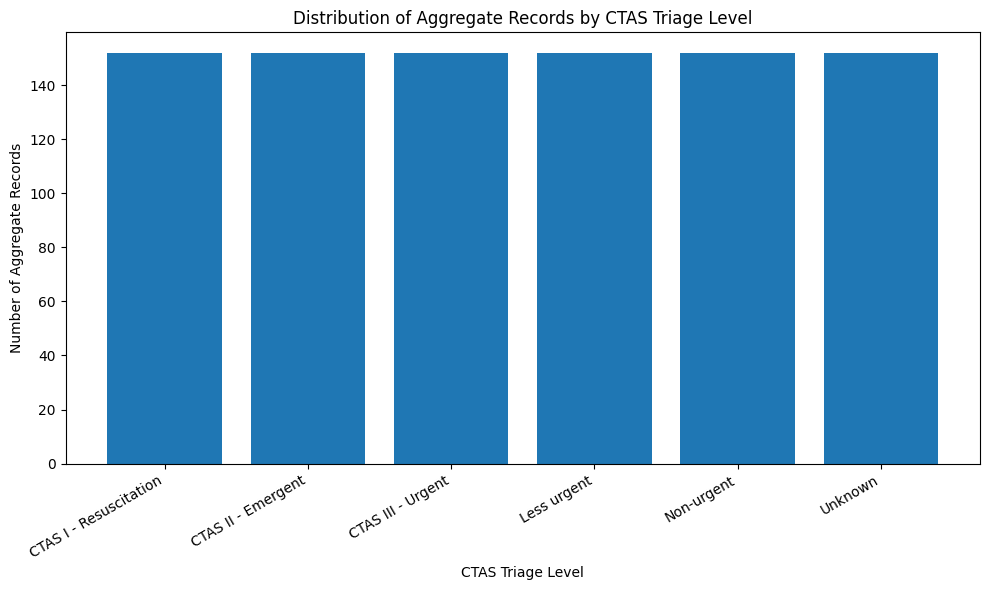

In [76]:
plt.figure(figsize=(10, 6))

ctas_counts_plot = (
    df["triage_level"]
    .value_counts()
    .sort_index()
)

plt.bar(
    ctas_counts_plot.index,
    ctas_counts_plot.values
)

plt.xlabel("CTAS Triage Level")

plt.ylabel("Number of Aggregate Records")

plt.title(
    "Distribution of Aggregate Records by CTAS Triage Level"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_10500\1212127786.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


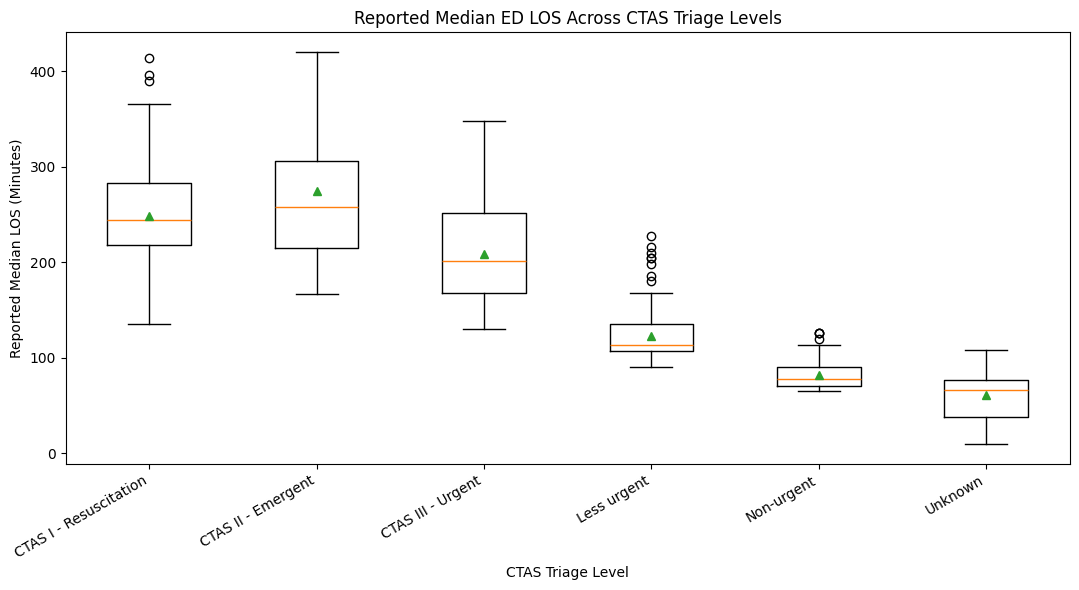

In [77]:
groups = []

labels = []

for level, group in df.groupby("triage_level"):

    values = (
        group["median_los_minutes"]
        .dropna()
        .values
    )

    if len(values) > 0:

        groups.append(values)

        labels.append(level)


plt.figure(figsize=(11, 6))

plt.boxplot(
    groups,
    labels=labels,
    showmeans=True
)

plt.xlabel("CTAS Triage Level")

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.title(
    "Reported Median ED LOS Across CTAS Triage Levels"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

In [78]:
required_columns = [
    "triage_level",
    "ed_visits",
    "median_los_minutes"
]

print("H1 DATA VALIDATION")
print("=" * 80)

for column in required_columns:

    print(
        f"{column:25} : "
        f"{'FOUND' if column in df.columns else 'MISSING'}"
    )


analysis_df = df[
    required_columns
].copy()

analysis_df = analysis_df.dropna(
    subset=required_columns
)

analysis_df = analysis_df[
    (analysis_df["ed_visits"] > 0) &
    (analysis_df["median_los_minutes"] >= 0)
].copy()


print("\nAfter validation:")

print(
    f"Records available : {len(analysis_df):,}"
)

print(
    f"CTAS groups       : "
    f"{analysis_df['triage_level'].nunique()}"
)

print(
    f"Total ED visits   : "
    f"{analysis_df['ed_visits'].sum():,.0f}"
)

print(
    f"Missing values    : "
    f"{analysis_df.isna().sum().sum()}"
)

print("\nCTAS groups:")

for group in sorted(
    analysis_df["triage_level"].unique()
):

    print(f"  • {group}")

H1 DATA VALIDATION
triage_level              : FOUND
ed_visits                 : FOUND
median_los_minutes        : FOUND

After validation:
Records available : 912
CTAS groups       : 6
Total ED visits   : 175,762,944
Missing values    : 0

CTAS groups:
  • CTAS I - Resuscitation
  • CTAS II - Emergent
  • CTAS III - Urgent
  • Less urgent
  • Non-urgent
  • Unknown


In [79]:
VALID_CTAS_LEVELS = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent"
]

h1_df = df[
    df["triage_level"].isin(VALID_CTAS_LEVELS)
].copy()

# Keep only variables required for H1
h1_df = h1_df[
    [
        "fiscal_year",
        "fiscal_year_start",
        "triage_level",
        "ed_visits",
        "median_los_minutes"
    ]
].copy()

# Remove invalid/missing observations
h1_df = h1_df.dropna(
    subset=[
        "triage_level",
        "ed_visits",
        "median_los_minutes"
    ]
)

h1_df = h1_df[
    (h1_df["ed_visits"] > 0) &
    (h1_df["median_los_minutes"] >= 0)
].copy()

print("=" * 80)
print("H1 ANALYSIS DATASET")
print("=" * 80)

print(f"Original records       : {len(df):,}")
print(f"Records after filtering: {len(h1_df):,}")
print(f"Records removed        : {len(df) - len(h1_df):,}")

print("\nCTAS levels included:")

for level in VALID_CTAS_LEVELS:
    print(
        f"  {level}: "
        f"{(h1_df['triage_level'] == level).sum():,} records"
    )

print("\nExcluded categories:")

excluded = sorted(
    set(df["triage_level"].dropna())
    - set(VALID_CTAS_LEVELS)
)

for category in excluded:
    print(f"  {category}")

H1 ANALYSIS DATASET
Original records       : 912
Records after filtering: 760
Records removed        : 152

CTAS levels included:
  CTAS I - Resuscitation: 152 records
  CTAS II - Emergent: 152 records
  CTAS III - Urgent: 152 records
  Less urgent: 152 records
  Non-urgent: 152 records

Excluded categories:
  Unknown


In [80]:
print("=" * 80)
print("WEIGHT VALIDATION")
print("=" * 80)

print("ED Visits data type:")
print(h1_df["ed_visits"].dtype)

print("\nNon-integer ED visit values:")

non_integer_weights = (
    h1_df["ed_visits"] % 1 != 0
).sum()

print(non_integer_weights)

print("\nMinimum ED visits:")
print(h1_df["ed_visits"].min())

print("\nMaximum ED visits:")
print(h1_df["ed_visits"].max())

print("\nTotal ED visits represented:")
print(
    f"{h1_df['ed_visits'].sum():,.0f}"
)

WEIGHT VALIDATION
ED Visits data type:
int64

Non-integer ED visit values:
0

Minimum ED visits:
1254

Maximum ED visits:
1165671

Total ED visits represented:
174,207,395


In [81]:
h1_summary = (
    h1_df
    .groupby("triage_level")
    .apply(
        lambda x: pd.Series({

            "records":
                len(x),

            "total_ed_visits":
                x["ed_visits"].sum(),

            "weighted_mean_los_minutes":
                weighted_mean(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "weighted_median_los_minutes":
                weighted_median(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "minimum_los_minutes":
                x["median_los_minutes"].min(),

            "maximum_los_minutes":
                x["median_los_minutes"].max()

        }),
        include_groups=False
    )
    .reset_index()
)

# Sort by CTAS clinical order
ctas_order = {
    "CTAS I - Resuscitation": 1,
    "CTAS II - Emergent": 2,
    "CTAS III - Urgent": 3,
    "Less urgent": 4,
    "Non-urgent": 5
}

h1_summary["ctas_order"] = (
    h1_summary["triage_level"]
    .map(ctas_order)
)

h1_summary = (
    h1_summary
    .sort_values("ctas_order")
    .drop(columns="ctas_order")
)

display(h1_summary)

,triage_level,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,CTAS I - Resuscitation,152.0000,"1,286,555.0000",281.6537,276.0000,135.0000,414.0000
1,CTAS II - Emergent,152.0000,"26,742,361.0000",291.0076,288.0000,167.0000,420.0000
2,CTAS III - Urgent,152.0000,"72,100,128.0000",212.6773,204.0000,130.0000,348.0000
3,Less urgent,152.0000,"58,990,020.0000",122.5444,114.0000,90.0000,228.0000
4,Non-urgent,152.0000,"15,088,331.0000",86.7624,80.0000,65.0000,126.0000


In [82]:
def weighted_kruskal_wallis(
    data,
    group_col,
    value_col,
    weight_col
):
    
    test_data = data[
        [group_col, value_col, weight_col]
    ].dropna().copy()

    test_data = test_data[
        test_data[weight_col] > 0
    ].copy()

    # Ensure weights are integers
    if not np.all(
        np.isclose(
            test_data[weight_col] % 1,
            0
        )
    ):
        raise ValueError(
            "Weights must be integer visit counts."
        )

    test_data[weight_col] = (
        test_data[weight_col]
        .astype(np.int64)
    )
    N = int(
        test_data[weight_col].sum()
    )
    value_weights = (
        test_data
        .groupby(value_col)[weight_col]
        .sum()
        .sort_index()
    )

    cumulative_before = (
        value_weights
        .cumsum()
        .shift(fill_value=0)
    )

    weighted_ranks = (
        cumulative_before
        + (value_weights + 1) / 2
    )


In [83]:
# ============================================================
# WEIGHTED KRUSKAL-WALLIS TEST
# ============================================================

def weighted_kruskal_wallis(
    data,
    group_col,
    value_col,
    weight_col
):
    
    test_data = data[
        [group_col, value_col, weight_col]
    ].dropna().copy()

    test_data = test_data[
        test_data[weight_col] > 0
    ].copy()

    # Ensure weights are integers
    if not np.all(
        np.isclose(
            test_data[weight_col] % 1,
            0
        )
    ):
        raise ValueError(
            "Weights must be integer visit counts."
        )

    test_data[weight_col] = (
        test_data[weight_col]
        .astype(np.int64)
    )

    #Total Frequency

    N = int(
        test_data[weight_col].sum()
    )

    # Rank unique LOS values using frequency weights


    value_weights = (
        test_data
        .groupby(value_col)[weight_col]
        .sum()
        .sort_index()
    )

    cumulative_before = (
        value_weights
        .cumsum()
        .shift(fill_value=0)
    )

    weighted_ranks = (
        cumulative_before
        + (value_weights + 1) / 2
    )

    # Map rank back to each row
    test_data["_rank"] = (
        test_data[value_col]
        .map(weighted_ranks)
    )

    # Group rank sums

    group_stats = (
        test_data
        .groupby(group_col)
        .apply(
            lambda x: pd.Series({

                "weight":
                    x[weight_col].sum(),

                "rank_sum":
                    (
                        x["_rank"]
                        * x[weight_col]
                    ).sum()

            }),
            include_groups=False
        )
    )

    # Raw H statistic

    H_raw = (
        12 /
        (N * (N + 1))
    ) * (
        (
            group_stats["rank_sum"] ** 2
            /
            group_stats["weight"]
        ).sum()
    ) - (
        3 * (N + 1)
    )

    # Tie correction

    tie_weights = value_weights.values

    tie_correction = (
        1 -
        (
            np.sum(
                tie_weights ** 3 -
                tie_weights
            )
            /
            (
                N ** 3 -
                N
            )
        )
    )

    H_corrected = (
        H_raw /
        tie_correction
    )

    degrees_freedom = (
        group_stats.shape[0] - 1
    )

    p_value = stats.chi2.sf(
        H_corrected,
        degrees_freedom
    )

    return {
        "H": H_corrected,
        "df": degrees_freedom,
        "p_value": p_value,
        "N_weight": N,
        "tie_correction": tie_correction,
        "group_stats": group_stats
    }

In [84]:
h1_result = weighted_kruskal_wallis(
    data=h1_df,
    group_col="triage_level",
    value_col="median_los_minutes",
    weight_col="ed_visits"
)

print("H1 - WEIGHTED KRUSKAL-WALLIS TEST")
print("-" * 80)

print(
    f"Test statistic (H): "
    f"{h1_result['H']:.6f}"
)

print(
    f"Degrees of freedom: "
    f"{h1_result['df']}"
)

print(
    f"P-value: "
    f"{h1_result['p_value']:.10f}"
)

print(
    f"Total frequency weight: "
    f"{h1_result['N_weight']:,}"
)

print(
    f"Tie correction: "
    f"{h1_result['tie_correction']:.10f}"
)

H1 - WEIGHTED KRUSKAL-WALLIS TEST
--------------------------------------------------------------------------------
Test statistic (H): 126264274.810189
Degrees of freedom: 4
P-value: 0.0000000000
Total frequency weight: 174,207,395
Tie correction: 1.0000001932


In [85]:
ALPHA = 0.05

p_value = h1_result["p_value"]

print("=" * 80)
print("H1 HYPOTHESIS DECISION")
print("=" * 80)

print("Significance level (α):", ALPHA)

print(
    f"P-value: {p_value:.10f}"
)

if p_value < ALPHA:

    print("\nDecision: REJECT H₀")

    print(
        "\nConclusion:"
    )

    print(
        "There is statistically significant evidence "
        "that reported median ED length of stay differs "
        "across CTAS triage levels in the aggregate "
        "NACRS data."
    )

else:

    print("\nDecision: FAIL TO REJECT H₀")

    print(
        "\nConclusion:"
    )

    print(
        "There is insufficient statistical evidence "
        "to conclude that reported median ED length "
        "of stay differs across CTAS triage levels."
    )

H1 HYPOTHESIS DECISION
Significance level (α): 0.05
P-value: 0.0000000000

Decision: REJECT H₀

Conclusion:
There is statistically significant evidence that reported median ED length of stay differs across CTAS triage levels in the aggregate NACRS data.


In [86]:
H = h1_result["H"]

k = h1_result["df"] + 1

N = h1_result["N_weight"]

epsilon_squared = (
    H - k + 1
) / (
    N - k
)

print("H1 EFFECT SIZE")
print("-" * 80)

print(
    f"Epsilon squared (ε²): "
    f"{epsilon_squared:.10f}"
)

H1 EFFECT SIZE
--------------------------------------------------------------------------------
Epsilon squared (ε²): 0.7247928507


In [87]:
h1_result_table = pd.DataFrame({

    "Hypothesis": [
        "H1"
    ],

    "Research_Question": [
        "Does reported median ED LOS differ across CTAS triage levels?"
    ],

    "Test": [
        "Weighted Kruskal-Wallis"
    ],

    "H_Statistic": [
        H
    ],

    "Degrees_of_Freedom": [
        h1_result["df"]
    ],

    "P_Value": [
        p_value
    ],

    "Epsilon_Squared": [
        epsilon_squared
    ],

    "Alpha": [
        ALPHA
    ],

    "Decision": [
        "Reject H0"
        if p_value < ALPHA
        else "Fail to Reject H0"
    ]

})

display(h1_result_table)

,Hypothesis,Research_Question,Test,H_Statistic,Degrees_of_Freedom,P_Value,Epsilon_Squared,Alpha,Decision
0,H1,Does reported median ED LOS differ across CTAS...,Weighted Kruskal-Wallis,"126,264,274.8102",4,0.0000,0.7248,0.0500,Reject H0


In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [89]:
CTAS_ORDER = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent"
]

# Create ordered categorical variable
h1_df["triage_level"] = pd.Categorical(
    h1_df["triage_level"],
    categories=CTAS_ORDER,
    ordered=True
)

# Sort
h1_df = h1_df.sort_values("triage_level")

In [90]:
CTAS_SHORT = {
    "CTAS I - Resuscitation": "CTAS I",
    "CTAS II - Emergent": "CTAS II",
    "CTAS III - Urgent": "CTAS III",
    "Less urgent": "Less Urgent",
    "Non-urgent": "Non-Urgent"
}

chart_labels = [
    CTAS_SHORT[x]
    for x in CTAS_ORDER
]

print("H1 visualization data prepared.")

H1 visualization data prepared.


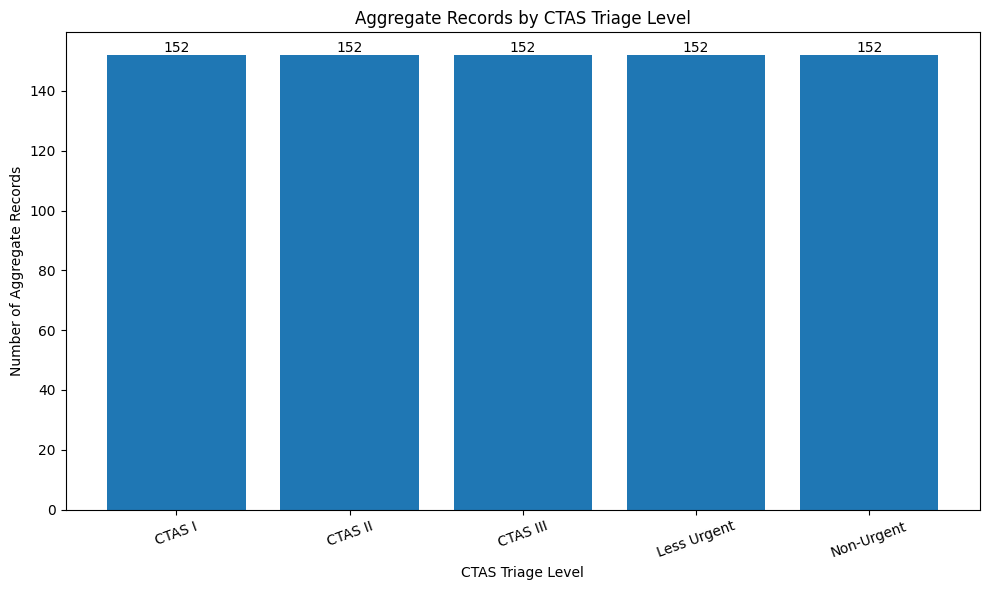

In [91]:
# NUMBER OF AGGREGATE RECORDS BY CTAS LEVEL

record_counts = (
    h1_df
    .groupby("triage_level", observed=True)
    .size()
    .reindex(CTAS_ORDER)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    chart_labels,
    record_counts.values
)

plt.title(
    "Aggregate Records by CTAS Triage Level"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Number of Aggregate Records"
)

plt.xticks(rotation=20)

# Add labels
for bar, value in zip(
    bars,
    record_counts.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

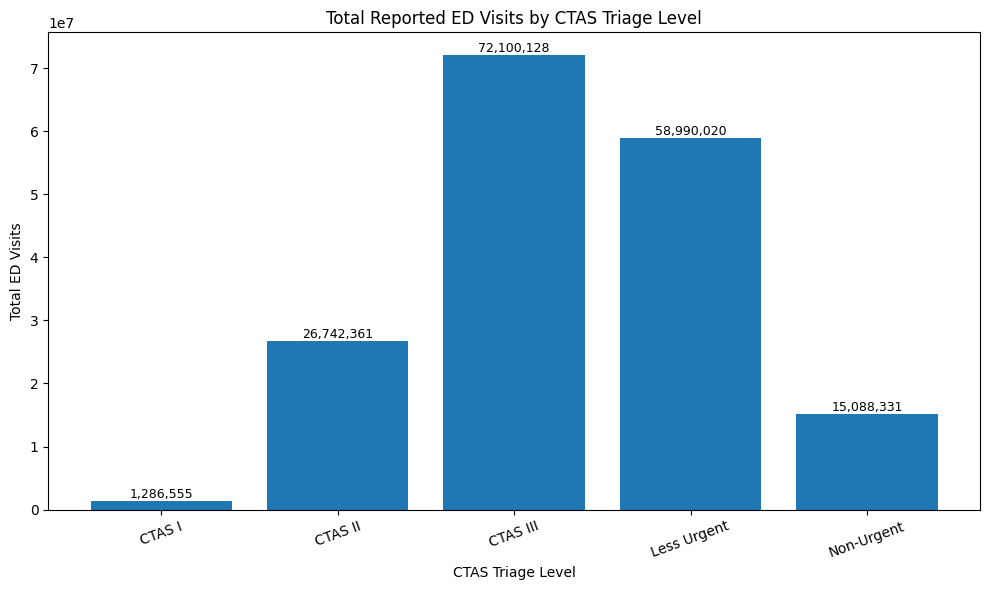

In [92]:
# TOTAL ED VISITS BY CTAS LEVEL

visit_summary = (
    h1_df
    .groupby("triage_level", observed=True)["ed_visits"]
    .sum()
    .reindex(CTAS_ORDER)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    chart_labels,
    visit_summary.values
)

plt.title(
    "Total Reported ED Visits by CTAS Triage Level"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Total ED Visits"
)

plt.xticks(rotation=20)

# Format labels
for bar, value in zip(
    bars,
    visit_summary.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

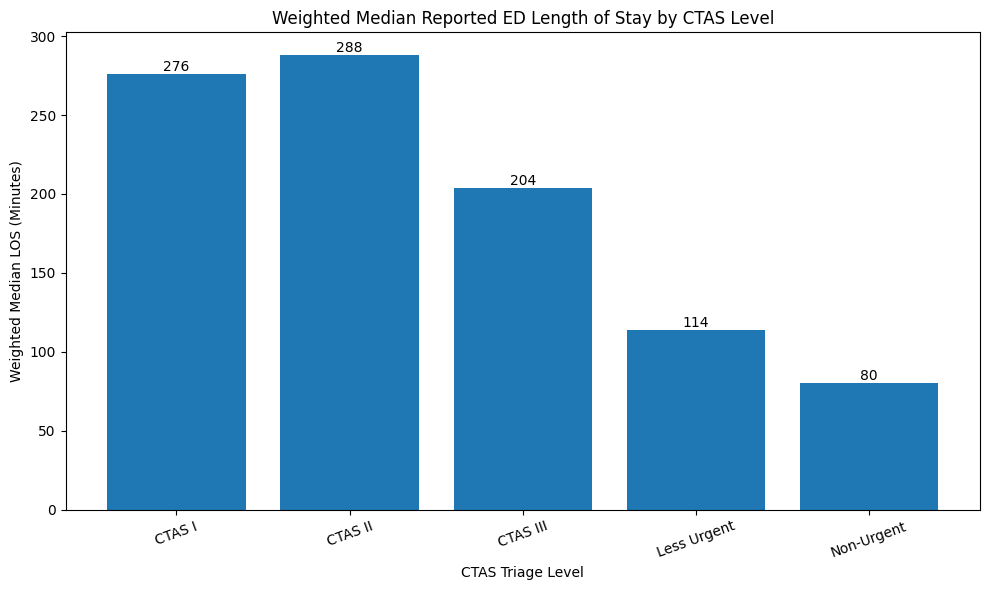

In [93]:
# WEIGHTED MEDIAN LOS BY CTAS

weighted_los = (
    h1_summary
    .set_index("triage_level")
    .reindex(CTAS_ORDER)
    ["weighted_median_los_minutes"]
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    chart_labels,
    weighted_los.values
)

plt.title(
    "Weighted Median Reported ED Length of Stay by CTAS Level"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Weighted Median LOS (Minutes)"
)

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    weighted_los.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

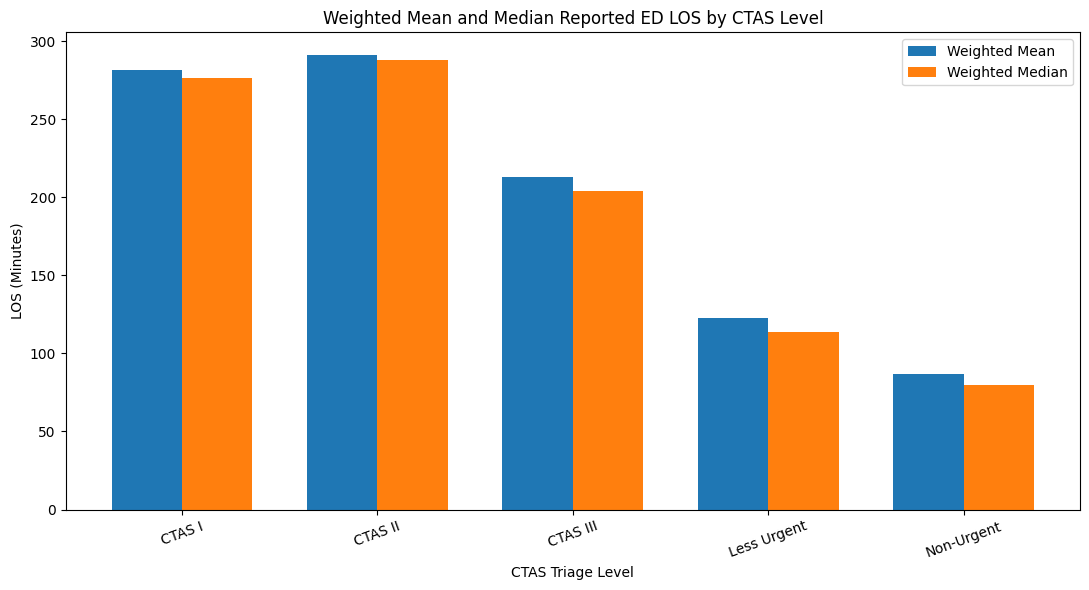

In [94]:
# WEIGHTED MEAN VS WEIGHTED MEDIAN LOS

mean_los = (
    h1_summary
    .set_index("triage_level")
    .reindex(CTAS_ORDER)
    ["weighted_mean_los_minutes"]
)

median_los = (
    h1_summary
    .set_index("triage_level")
    .reindex(CTAS_ORDER)
    ["weighted_median_los_minutes"]
)

x = np.arange(len(CTAS_ORDER))

width = 0.36

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    mean_los.values,
    width,
    label="Weighted Mean"
)

plt.bar(
    x + width / 2,
    median_los.values,
    width,
    label="Weighted Median"
)

plt.xticks(
    x,
    chart_labels,
    rotation=20
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "LOS (Minutes)"
)

plt.title(
    "Weighted Mean and Median Reported ED LOS by CTAS Level"
)

plt.legend()

plt.tight_layout()

plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_10500\1931070019.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


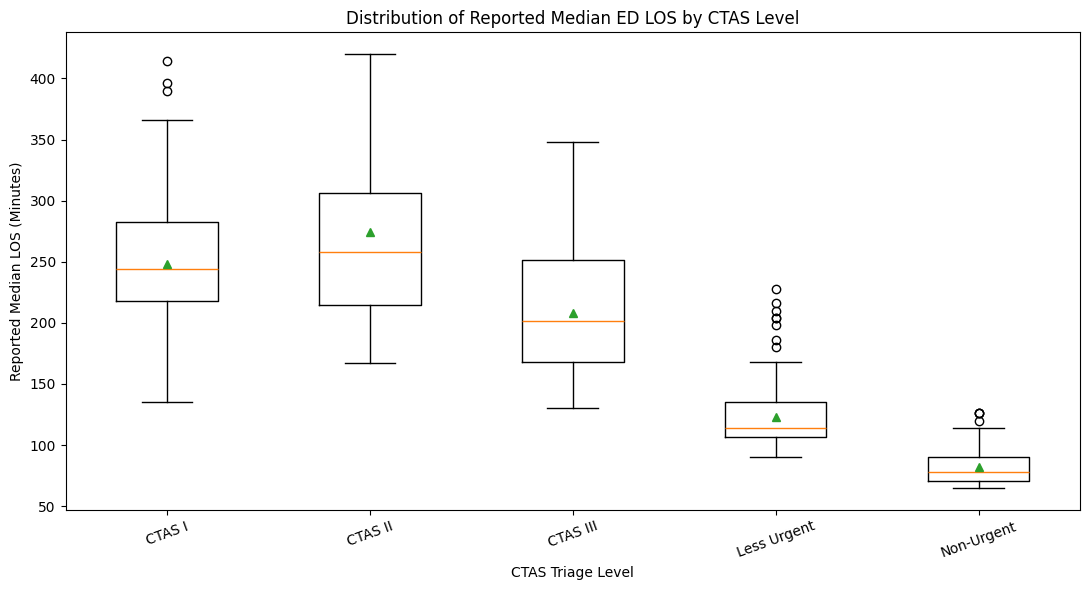

In [95]:
# LOS DISTRIBUTION BY CTAS

box_data = []

for level in CTAS_ORDER:

    values = (
        h1_df.loc[
            h1_df["triage_level"] == level,
            "median_los_minutes"
        ]
        .dropna()
        .values
    )

    box_data.append(values)


plt.figure(figsize=(11, 6))

plt.boxplot(
    box_data,
    labels=chart_labels,
    showmeans=True
)

plt.title(
    "Distribution of Reported Median ED LOS by CTAS Level"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

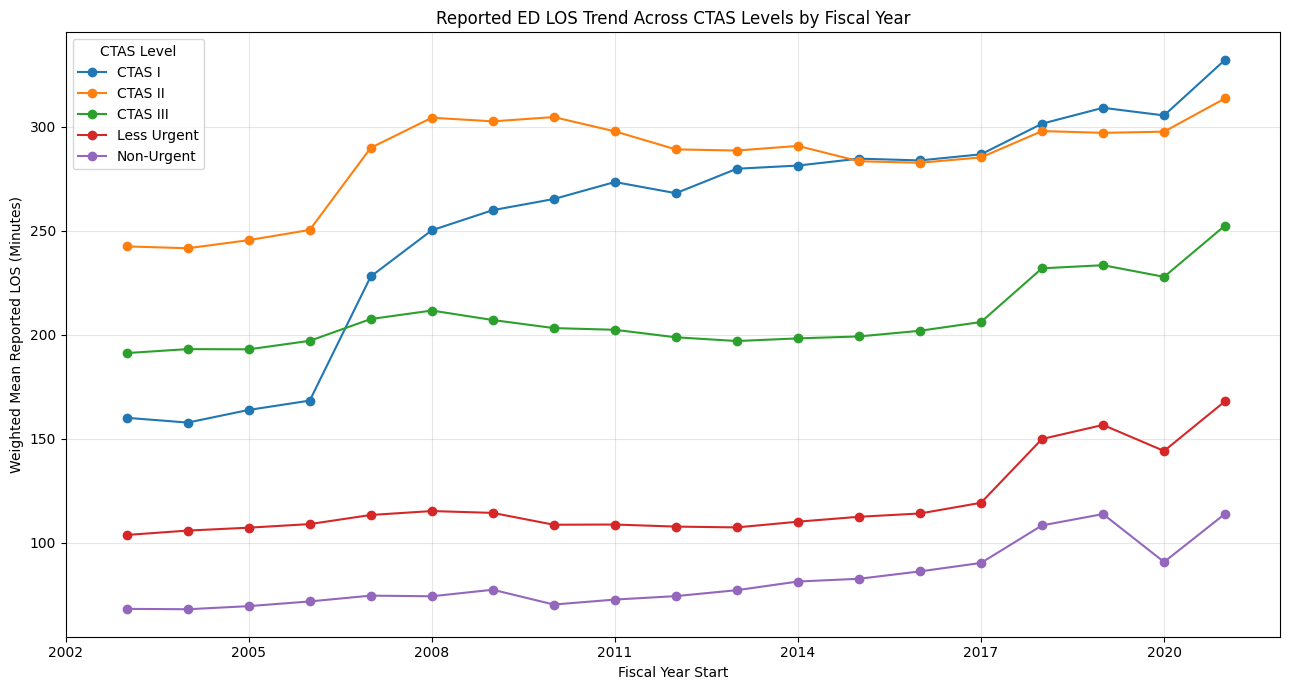

In [96]:
plt.figure(figsize=(13, 7))

for level in CTAS_ORDER:

    subset = year_ctas[
        year_ctas["triage_level"] == level
    ]

    plt.plot(
        subset["fiscal_year_start"],
        subset["weighted_mean_los"],
        marker="o",
        label=CTAS_SHORT[level]
    )

# X-axis categories every 3 years
year_ticks = list(range(2002, 2022, 3))

plt.xticks(
    year_ticks,
    [str(year) for year in year_ticks]
)

plt.title(
    "Reported ED LOS Trend Across CTAS Levels by Fiscal Year"
)

plt.xlabel(
    "Fiscal Year Start"
)

plt.ylabel(
    "Weighted Mean Reported LOS (Minutes)"
)

plt.legend(
    title="CTAS Level"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

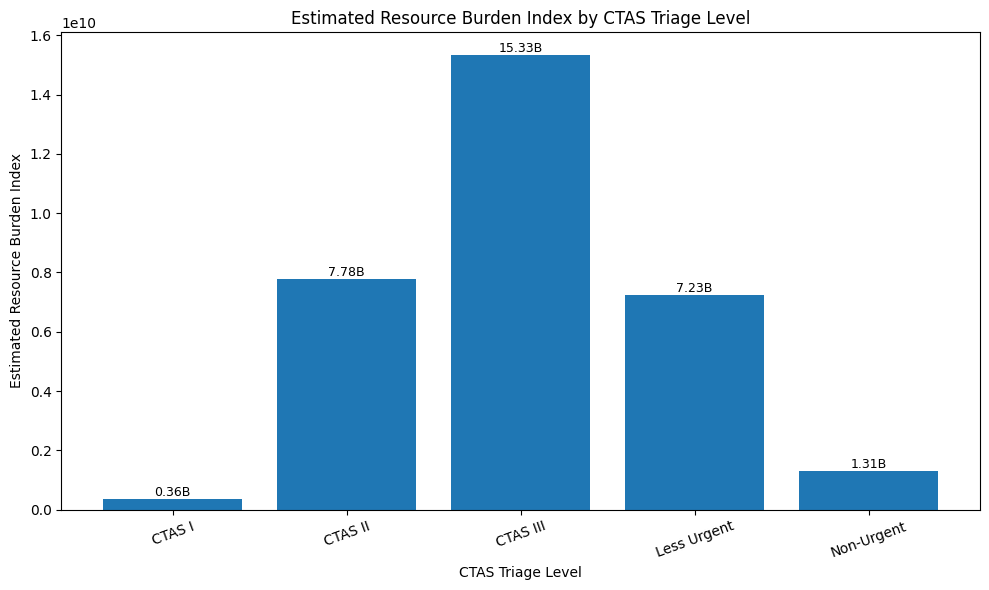

In [97]:
# ESTIMATED RESOURCE BURDEN INDEX BY CTAS

h1_erbi = (
    h1_df
    .assign(
        erbi=lambda x:
            x["ed_visits"] *
            x["median_los_minutes"]
    )
    .groupby(
        "triage_level",
        observed=True
    )["erbi"]
    .sum()
    .reindex(CTAS_ORDER)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    chart_labels,
    h1_erbi.values
)

plt.title(
    "Estimated Resource Burden Index by CTAS Triage Level"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Estimated Resource Burden Index"
)

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    h1_erbi.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value / 1e9:.2f}B",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

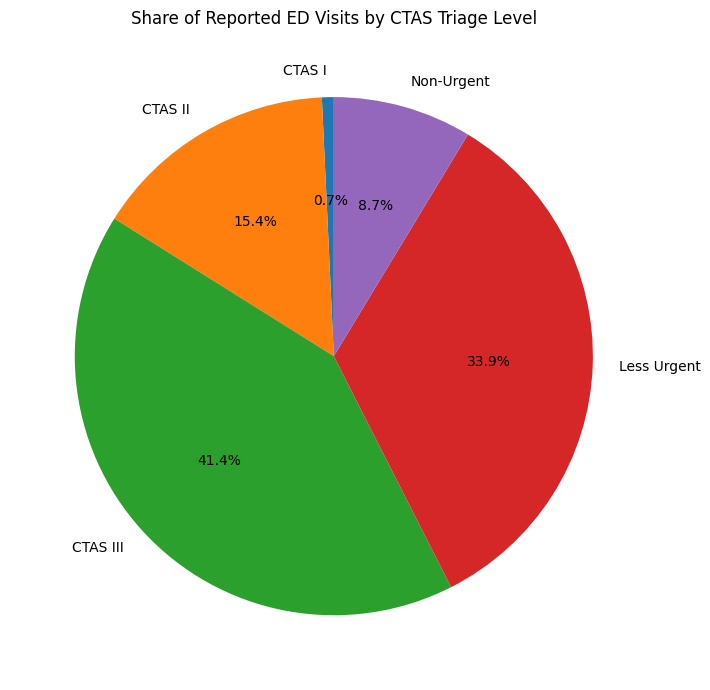

In [98]:
# ED VISIT SHARE BY CTAS

visit_share = (
    visit_summary /
    visit_summary.sum()
) * 100

plt.figure(figsize=(9, 7))

plt.pie(
    visit_share.values,
    labels=chart_labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Share of Reported ED Visits by CTAS Triage Level"
)

plt.tight_layout()

plt.show()

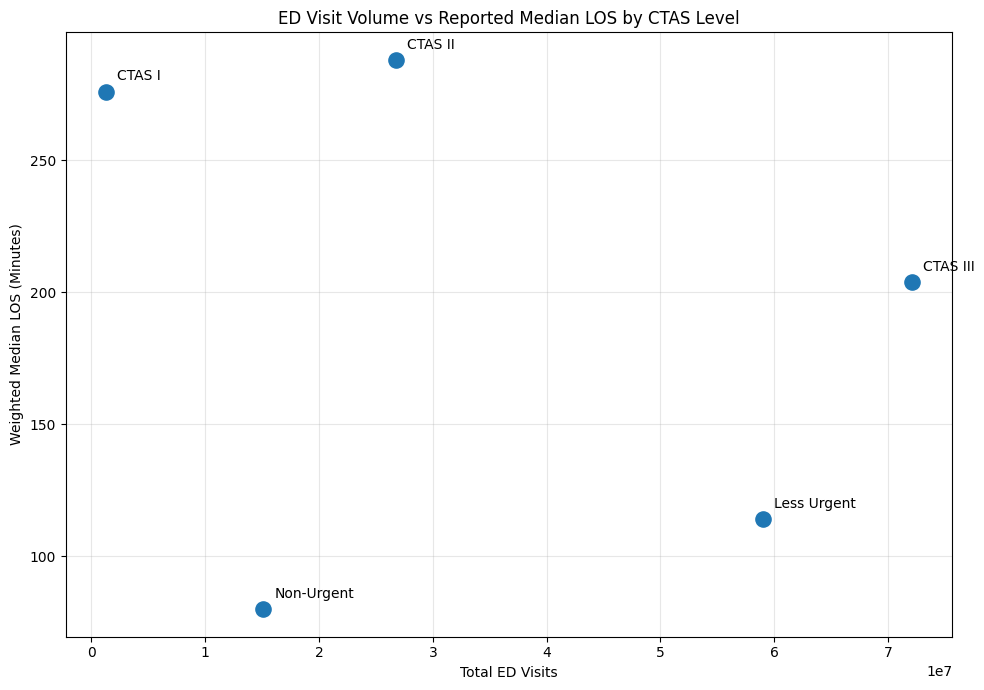

In [99]:
# CTAS VOLUME VS LOS

scatter_data = pd.DataFrame({

    "CTAS": chart_labels,

    "ED_Visits":
        visit_summary.values,

    "Weighted_Median_LOS":
        weighted_los.values

})

plt.figure(figsize=(10, 7))

plt.scatter(
    scatter_data["ED_Visits"],
    scatter_data["Weighted_Median_LOS"],
    s=120
)

for _, row in scatter_data.iterrows():

    plt.annotate(
        row["CTAS"],
        (
            row["ED_Visits"],
            row["Weighted_Median_LOS"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel(
    "Total ED Visits"
)

plt.ylabel(
    "Weighted Median LOS (Minutes)"
)

plt.title(
    "ED Visit Volume vs Reported Median LOS by CTAS Level"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

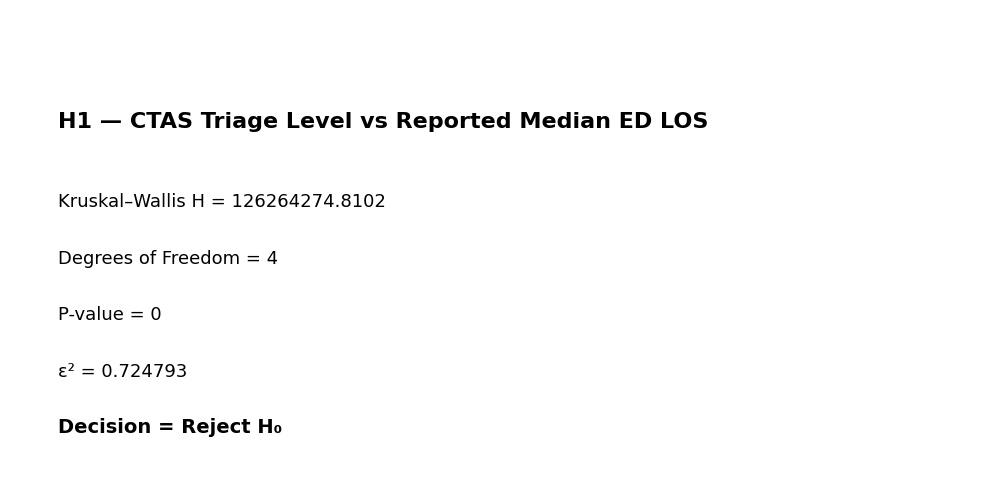

In [100]:
# H1 STATISTICAL RESULT

p_value = h1_result["p_value"]

epsilon_squared = (
    (h1_result["H"] - h1_result["df"])
    /
    (
        h1_result["N_weight"]
        - h1_result["df"]
        - 1
    )
)

decision = (
    "Reject H₀"
    if p_value < 0.05
    else
    "Fail to Reject H₀"
)

plt.figure(figsize=(10, 5))

plt.axis("off")

plt.text(
    0.05,
    0.75,
    "H1 — CTAS Triage Level vs Reported Median ED LOS",
    fontsize=16,
    fontweight="bold"
)

plt.text(
    0.05,
    0.58,
    f"Kruskal–Wallis H = {h1_result['H']:.4f}",
    fontsize=13
)

plt.text(
    0.05,
    0.46,
    f"Degrees of Freedom = {h1_result['df']}",
    fontsize=13
)

plt.text(
    0.05,
    0.34,
    f"P-value = {p_value:.6g}",
    fontsize=13
)

plt.text(
    0.05,
    0.22,
    f"ε² = {epsilon_squared:.6f}",
    fontsize=13
)

plt.text(
    0.05,
    0.10,
    f"Decision = {decision}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()